In [1]:
import math
from collections import defaultdict, deque

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

In [2]:
PLACE = "Nancy, France"
NETWORK_TYPE = "drive"
RANDOM_SEED = 42
SIMULATION_STEPS = 90
CYCLE_TIME = 60
MIN_GREEN = 15
MAX_GREEN = 45
ARRIVAL_RATE = 18
NUM_OD_PAIRS = 40
BETWEENNESS_K = 80
ALPHA = 0.75
BETA = 0.25

rng = np.random.default_rng(RANDOM_SEED)
ox.settings.use_cache = True

In [3]:
def parse_numeric(value, default):
    if value is None:
        return default
    if isinstance(value, list):
        value = value[0]
    if isinstance(value, str):
        digits = "".join(ch for ch in value if ch.isdigit() or ch == ".")
        return float(digits) if digits else default
    return float(value)


def collapse_multidigraph(multigraph):
    graph = nx.DiGraph()
    for node, data in multigraph.nodes(data=True):
        graph.add_node(node, **data)

    for u, v, data in multigraph.edges(data=True):
        edge_data = dict(data)
        edge_data["length"] = float(edge_data.get("length", 1.0))
        if graph.has_edge(u, v):
            if edge_data["length"] < graph[u][v]["length"]:
                graph[u][v].update(edge_data)
        else:
            graph.add_edge(u, v, **edge_data)

    return graph

In [17]:
raw_graph = ox.graph_from_place(PLACE, network_type=NETWORK_TYPE, simplify=True)
largest_component = max(nx.strongly_connected_components(raw_graph), key=len)
raw_graph = raw_graph.subgraph(largest_component).copy()

G = collapse_multidigraph(raw_graph)
G.graph["crs"] = raw_graph.graph.get("crs")

for u, v, data in G.edges(data=True):
    length = float(data.get("length", 1.0))
    speed_kph = parse_numeric(data.get("maxspeed"), 35.0)
    lanes = max(1, int(round(parse_numeric(data.get("lanes"), 1.0))))
    travel_time = length / max(speed_kph * 1000 / 3600, 1.0)

    data["length"] = length
    data["speed_kph"] = speed_kph
    data["lanes"] = lanes
    data["travel_time"] = travel_time
    data["capacity_per_cycle"] = max(1, int(lanes * 8))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 1333
Edges: 2771


In [18]:
k_value = min(BETWEENNESS_K, max(10, G.number_of_nodes() - 1))
betweenness = nx.betweenness_centrality(
    G,
    k=k_value,
    normalized=True,
    weight="travel_time",
    seed=RANDOM_SEED,
    endpoints=False,
)

max_bc = max(betweenness.values()) if betweenness else 1.0
node_importance = {
    node: (value / max_bc if max_bc else 0.0)
    for node, value in betweenness.items()
}
nx.set_node_attributes(G, node_importance, "betweenness_norm")

candidate_nodes = [
    node
    for node in G.nodes()
    if G.in_degree(node) > 0 and G.out_degree(node) > 0
]

print(f"Candidate intersections: {len(candidate_nodes)}")

Candidate intersections: 1333


In [19]:
route_bank = []
route_keys = set()
attempts = 0
max_attempts = NUM_OD_PAIRS * 40

while len(route_bank) < NUM_OD_PAIRS and attempts < max_attempts:
    origin, destination = rng.choice(candidate_nodes, size=2, replace=False)
    attempts += 1
    if (origin, destination) in route_keys:
        continue

    try:
        path = nx.shortest_path(G, origin, destination, weight="travel_time")
    except nx.NetworkXNoPath:
        continue

    if len(path) < 4:
        continue

    route_edges = list(zip(path[:-1], path[1:]))
    route_bank.append({
        "origin": origin,
        "destination": destination,
        "path": path,
        "edges": route_edges,
    })
    route_keys.add((origin, destination))

print(f"Routes prepared: {len(route_bank)}")

Routes prepared: 40


In [20]:
def build_demand_schedule(steps, arrival_rate, seed):
    local_rng = np.random.default_rng(seed)
    schedule = []

    for _ in range(steps):
        arrivals = int(local_rng.poisson(arrival_rate))
        if arrivals == 0:
            schedule.append([])
            continue

        chosen_routes = local_rng.integers(0, len(route_bank), size=arrivals)
        schedule.append(chosen_routes.tolist())

    return schedule


demand_schedule = build_demand_schedule(
    SIMULATION_STEPS,
    ARRIVAL_RATE,
    RANDOM_SEED,
)

total_arrivals = sum(len(step) for step in demand_schedule)
print(f"Vehicles scheduled: {total_arrivals}")

Vehicles scheduled: 1646


In [21]:
def make_empty_edge_queues(graph):
    return {edge: deque() for edge in graph.edges()}


def downstream_queue_mean(graph, edge_queues, edge):
    _, node = edge
    outgoing = list(graph.out_edges(node))
    if not outgoing:
        return 0.0
    return float(np.mean([len(edge_queues[next_edge]) for next_edge in outgoing]))


def service_capacity(graph, edge, green_time):
    capacity = graph.edges[edge]["capacity_per_cycle"]
    scaled_capacity = capacity * (green_time / CYCLE_TIME)
    return max(1, int(math.floor(scaled_capacity)))

In [22]:
def choose_edge_for_node(graph, edge_queues, node, controller, step):
    incoming = list(graph.in_edges(node))
    if not incoming:
        return None, 0

    if controller == "fixed":
        selected_edge = incoming[step % len(incoming)]
        return selected_edge, CYCLE_TIME / max(1, len(incoming))

    if controller == "backpressure":
        best_edge = None
        best_score = -np.inf

        for edge in incoming:
            queue_now = len(edge_queues[edge])
            score = queue_now - downstream_queue_mean(graph, edge_queues, edge)
            if score > best_score:
                best_score = score
                best_edge = edge

        return best_edge, CYCLE_TIME / max(1, len(incoming))

    if controller == "proposed":
        node_importance = graph.nodes[node].get("betweenness_norm", 0.0)
        max_local_queue = max(len(edge_queues[edge]) for edge in incoming) or 1
        best_edge = None
        best_priority = -np.inf

        for edge in incoming:
            load_norm = len(edge_queues[edge]) / max_local_queue
            priority = ALPHA * load_norm + BETA * node_importance
            if priority > best_priority:
                best_priority = priority
                best_edge = edge

        green_time = MIN_GREEN + (MAX_GREEN - MIN_GREEN) * max(0.0, best_priority)
        return best_edge, min(MAX_GREEN, green_time)

    raise ValueError(f"Unknown controller: {controller}")

In [23]:
def run_simulation(graph, route_bank, demand_schedule, controller):
    edge_queues = make_empty_edge_queues(graph)
    queue_history = []
    completed_travel_times = []
    total_injected = 0

    for step, arrivals in enumerate(demand_schedule):
        transfers = []

        for node in graph.nodes():
            selected_edge, green_time = choose_edge_for_node(
                graph,
                edge_queues,
                node,
                controller,
                step,
            )
            if selected_edge is None:
                continue

            move_count = min(
                len(edge_queues[selected_edge]),
                service_capacity(graph, selected_edge, green_time),
            )

            for _ in range(move_count):
                vehicle = edge_queues[selected_edge].popleft()
                transfers.append(vehicle)

        for vehicle in transfers:
            vehicle["edge_pos"] += 1
            route_edges = route_bank[vehicle["route_id"]]["edges"]

            if vehicle["edge_pos"] >= len(route_edges):
                completed_travel_times.append(step - vehicle["start_step"] + 1)
            else:
                next_edge = route_edges[vehicle["edge_pos"]]
                edge_queues[next_edge].append(vehicle)

        for route_id in arrivals:
            first_edge = route_bank[route_id]["edges"][0]
            edge_queues[first_edge].append({
                "route_id": route_id,
                "edge_pos": 0,
                "start_step": step,
            })
            total_injected += 1

        queue_history.append(sum(len(queue) for queue in edge_queues.values()))

    return {
        "controller": controller,
        "avg_queue_length": float(np.mean(queue_history)) if queue_history else 0.0,
        "avg_travel_time": float(np.mean(completed_travel_times)) if completed_travel_times else np.nan,
        "throughput": len(completed_travel_times),
        "completion_ratio": len(completed_travel_times) / total_injected if total_injected else 0.0,
        "queue_history": queue_history,
    }

In [24]:
controllers = ["fixed", "backpressure", "proposed"]
results = [
    run_simulation(G, route_bank, demand_schedule, controller)
    for controller in controllers
]

metrics_df = pd.DataFrame(
    [
        {
            "Controller": result["controller"],
            "Average Queue Length": round(result["avg_queue_length"], 2),
            "Average Travel Time": round(result["avg_travel_time"], 2),
            "Throughput": result["throughput"],
            "Completion Ratio": round(result["completion_ratio"], 3),
        }
        for result in results
    ]
).sort_values("Average Queue Length")

metrics_df

,Controller,Average Queue Length,Average Travel Time,Throughput,Completion Ratio
2,proposed,516.66,33.70,963,0.585
1,backpressure,540.36,34.85,895,0.544
0,fixed,693.84,44.49,461,0.280


In [25]:
print(
    "Methodology note: OSM provides the real road network and road attributes. "
    "Traffic queues and arrivals are simulated so every controller is tested under the same demand."
)

Methodology note: OSM provides the real road network and road attributes. Traffic queues and arrivals are simulated so every controller is tested under the same demand.


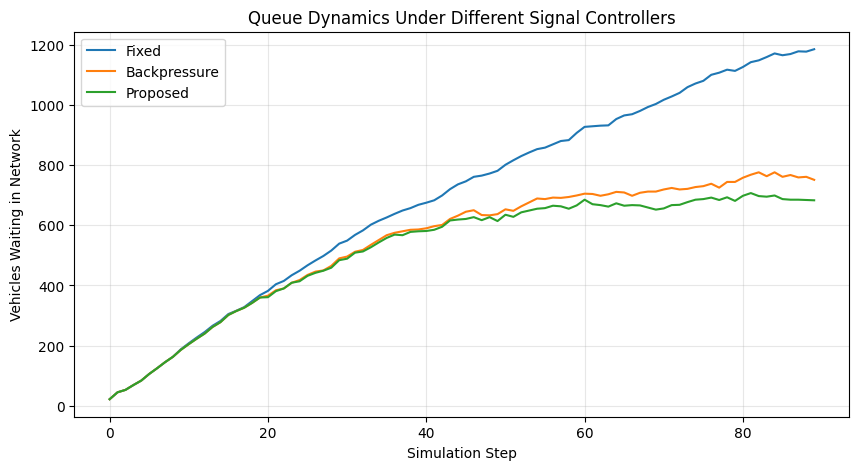

In [26]:
plt.figure(figsize=(10, 5))
for result in results:
    plt.plot(result["queue_history"], label=result["controller"].title())

plt.xlabel("Simulation Step")
plt.ylabel("Vehicles Waiting in Network")
plt.title("Queue Dynamics Under Different Signal Controllers")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

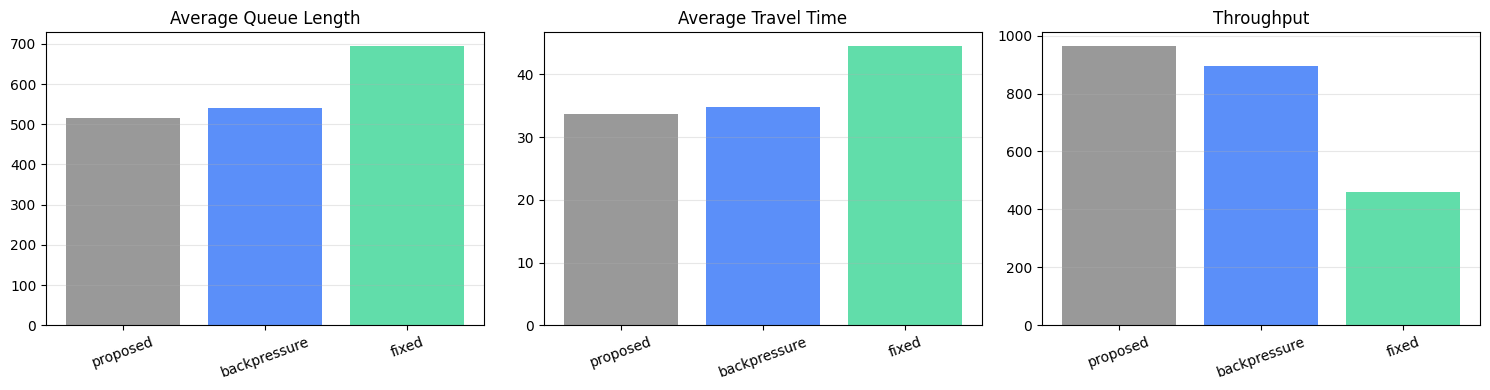

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_columns = [
    ("Average Queue Length", "Average Queue Length"),
    ("Average Travel Time", "Average Travel Time"),
    ("Throughput", "Throughput"),
]

for ax, (column, title) in zip(axes, plot_columns):
    ax.bar(metrics_df["Controller"], metrics_df[column], color=["#999999", "#5B8FF9", "#61DDAA"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
top_nodes = sorted(
    G.nodes(data=True),
    key=lambda item: item[1].get("betweenness_norm", 0.0),
    reverse=True,
 )[:10]

centrality_df = pd.DataFrame(
    [
        {
            "node": node,
            "betweenness_norm": round(data.get("betweenness_norm", 0.0), 4),
            "in_degree": G.in_degree(node),
            "out_degree": G.out_degree(node),
        }
        for node, data in top_nodes
    ]
 )

centrality_df

,node,betweenness_norm,in_degree,out_degree
0,129997246,1.0000,2,2
1,10532166,0.9417,2,2
2,9903237,0.9412,3,3
3,280577928,0.8704,3,3
4,10531864,0.8677,2,2
5,10533601,0.8567,2,2
6,10709093,0.8526,2,2
7,1732954761,0.8340,3,3
8,10532687,0.8225,2,2
9,13011651572,0.8213,2,2


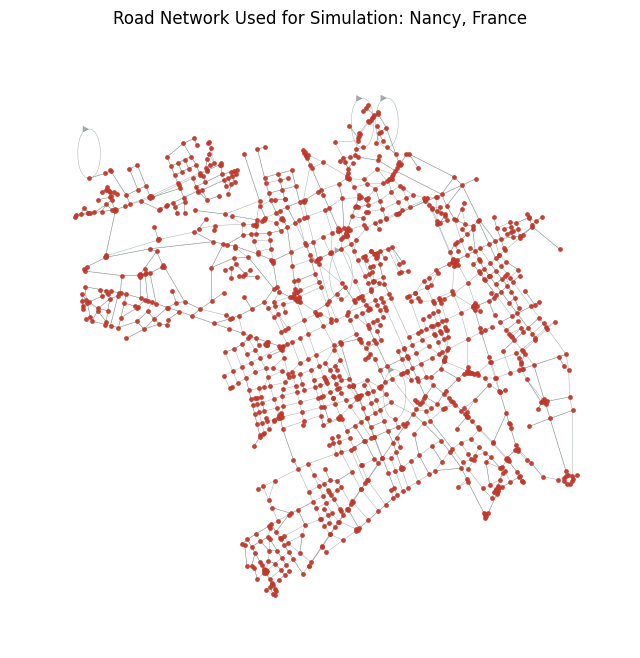

In [30]:
positions = {
    node: (data["x"], data["y"])
    for node, data in G.nodes(data=True)
}

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_edges(
    G,
    pos=positions,
    ax=ax,
    edge_color="#7f8c8d",
    width=0.35,
    alpha=0.7,
    arrows=False,
)
nx.draw_networkx_nodes(
    G,
    pos=positions,
    ax=ax,
    node_size=6,
    node_color="#c0392b",
    alpha=0.9,
)
ax.set_title(f"Road Network Used for Simulation: {PLACE}")
ax.set_axis_off()
plt.show()